**Exploring the socioeconomic variables**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry

In [2]:
df = pd.read_csv('../owid_covid_data.csv')

Which countries are represented?

In [4]:
df['country'].unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Asia excl. China',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'England

We see that some the "countries" are actually groups of countries such as "Africa", "European Union", and "World". The data for these locations is likely aggregated from all countries belonging to those categories. We may want to drop these rows to focus on individual countries.

In [5]:
non_countries = ['Africa', 'Asia', 'Asia excl. China', 'Europe', 'European Union (27)', 'High-income countries', 'Low-income countries', 'Lower-middle-income countries', 'North America', 'Oceania', 'South America', 'Summer Olympics 2020', 'Upper-middle-income countries', 'Winter Olympics 2022', 'World', 'World excl. China', 'World excl. China and South Korea', 'World excl. China, South Korea, Japan and Singapore']

Some socioeconomic variables that seem of interest and have reliable measurements:

In [6]:
cols = ['population_density', 'median_age', 'gdp_per_capita', 'extreme_poverty', 'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy']

How often is the measurement of each variable updated for each country? In other words, how many unique values of each variable are recorded for each country?

In [7]:
df_counts = df.groupby('country')[cols].nunique().reset_index()

#Exclude non-country countries
df_counts = df_counts[~df_counts['country'].isin(non_countries)]
df_counts

,country,population_density,median_age,gdp_per_capita,extreme_poverty,handwashing_facilities,hospital_beds_per_thousand,life_expectancy
0,Afghanistan,1,1,1,0,1,1,1
2,Albania,1,1,1,1,0,1,1
3,Algeria,1,1,1,1,1,1,1
4,American Samoa,1,1,0,0,0,0,1
5,Andorra,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...
252,Wallis and Futuna,1,1,0,0,0,0,1
253,Western Sahara,1,1,0,0,0,0,1
259,Yemen,1,1,0,1,1,1,1
260,Zambia,1,1,1,1,1,0,1


In [8]:
for col in cols:
    print(col, df_counts[col].unique())

population_density [1 0]
median_age [1 0]
gdp_per_capita [1 0]
extreme_poverty [0 1]
handwashing_facilities [1 0]
hospital_beds_per_thousand [1 0]
life_expectancy [1 0]


We see that each variable has at one measurement recorded for each country. For some variables and countries, there is no measurement, only NaN.

For how many countries is each variable recorded?

In [9]:
df_counts[cols].sum()

population_density            233
median_age                    237
gdp_per_capita                194
extreme_poverty               163
handwashing_facilities        120
hospital_beds_per_thousand    149
life_expectancy               237
dtype: int64

We see that many countries do not have handwashing_facilities recorded.

For how many countries in the top 10 by GDP is each variable recorded?

In [10]:
#The top 10 countries in the world by GDP (according to Wikipedia):
top_10_gdp = ['United States', 'China', 'Germany', 'Japan', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil']
df_top10 = df_counts[df_counts['country'].isin(top_10_gdp)]
df_top10[cols].sum()

population_density            10
median_age                    10
gdp_per_capita                10
extreme_poverty               10
handwashing_facilities         2
hospital_beds_per_thousand    10
life_expectancy               10
dtype: int64

In [11]:
df_top10[['country', 'handwashing_facilities']]

,country,handwashing_facilities
31,Brazil,0
45,China,1
79,France,0
85,Germany,0
104,India,1
111,Italy,0
113,Japan,0
188,Russia,0
241,United Kingdom,0
242,United States,0


We see that only India and China have measurements of handwashing facilities. We may want to exclude this variables so we aren't missing measurements for eight of the top ten countries by GDP.

If we only keep countries that have measurements of every variable except handwashing facilities, how many countries are left?

In [12]:
df_counts_new = df_counts.drop(columns = ['handwashing_facilities'])
df_counts_new = df_counts_new[(df_counts_new != 0).all(axis=1)]
countries_kept = list(df_counts_new['country'])

In [13]:
print(countries_kept)

['Albania', 'Algeria', 'Armenia', 'Australia', 'Austria', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Burundi', 'Canada', 'Central African Republic', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kazakhstan', 'Kiribati', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Nepal', 'Netherlands', 'Nicaragua', 'Niger', 'North Macedonia', 'Norway', 'Pakistan', 'Panama', 'Paraguay'

In [14]:
print(len(countries_kept))

119


We see that there are 119 countries left, including the top 10 countries by GDP.

If we only keep the variables mentioned above and we only keep countries for which all variables are recorded, what do the correlations between variables look like? What about the correlations between the variables and total deaths per million?

In [15]:
#Variables that we decided not to drop
newcols = ['population_density', 'median_age', 'gdp_per_capita', 'extreme_poverty', 'hospital_beds_per_thousand', 'life_expectancy']
df_vars = df.drop_duplicates(subset = 'country', keep = 'last')[['country'] + ['total_deaths_per_million'] + newcols]
df_vars = df_vars[df_vars['country'].isin(countries_kept)]

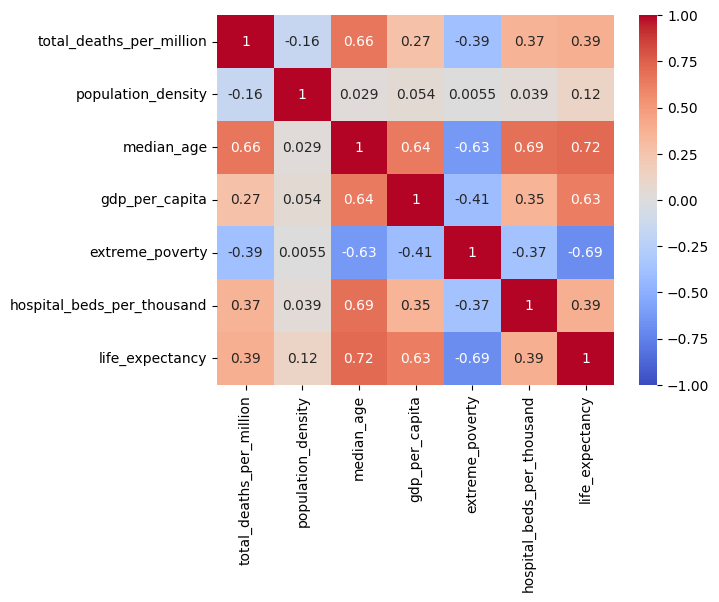

In [16]:
sns.heatmap(df_vars[['total_deaths_per_million'] + newcols].corr(), vmin = -1, vmax = 1, annot = True, cmap = 'coolwarm')
pass

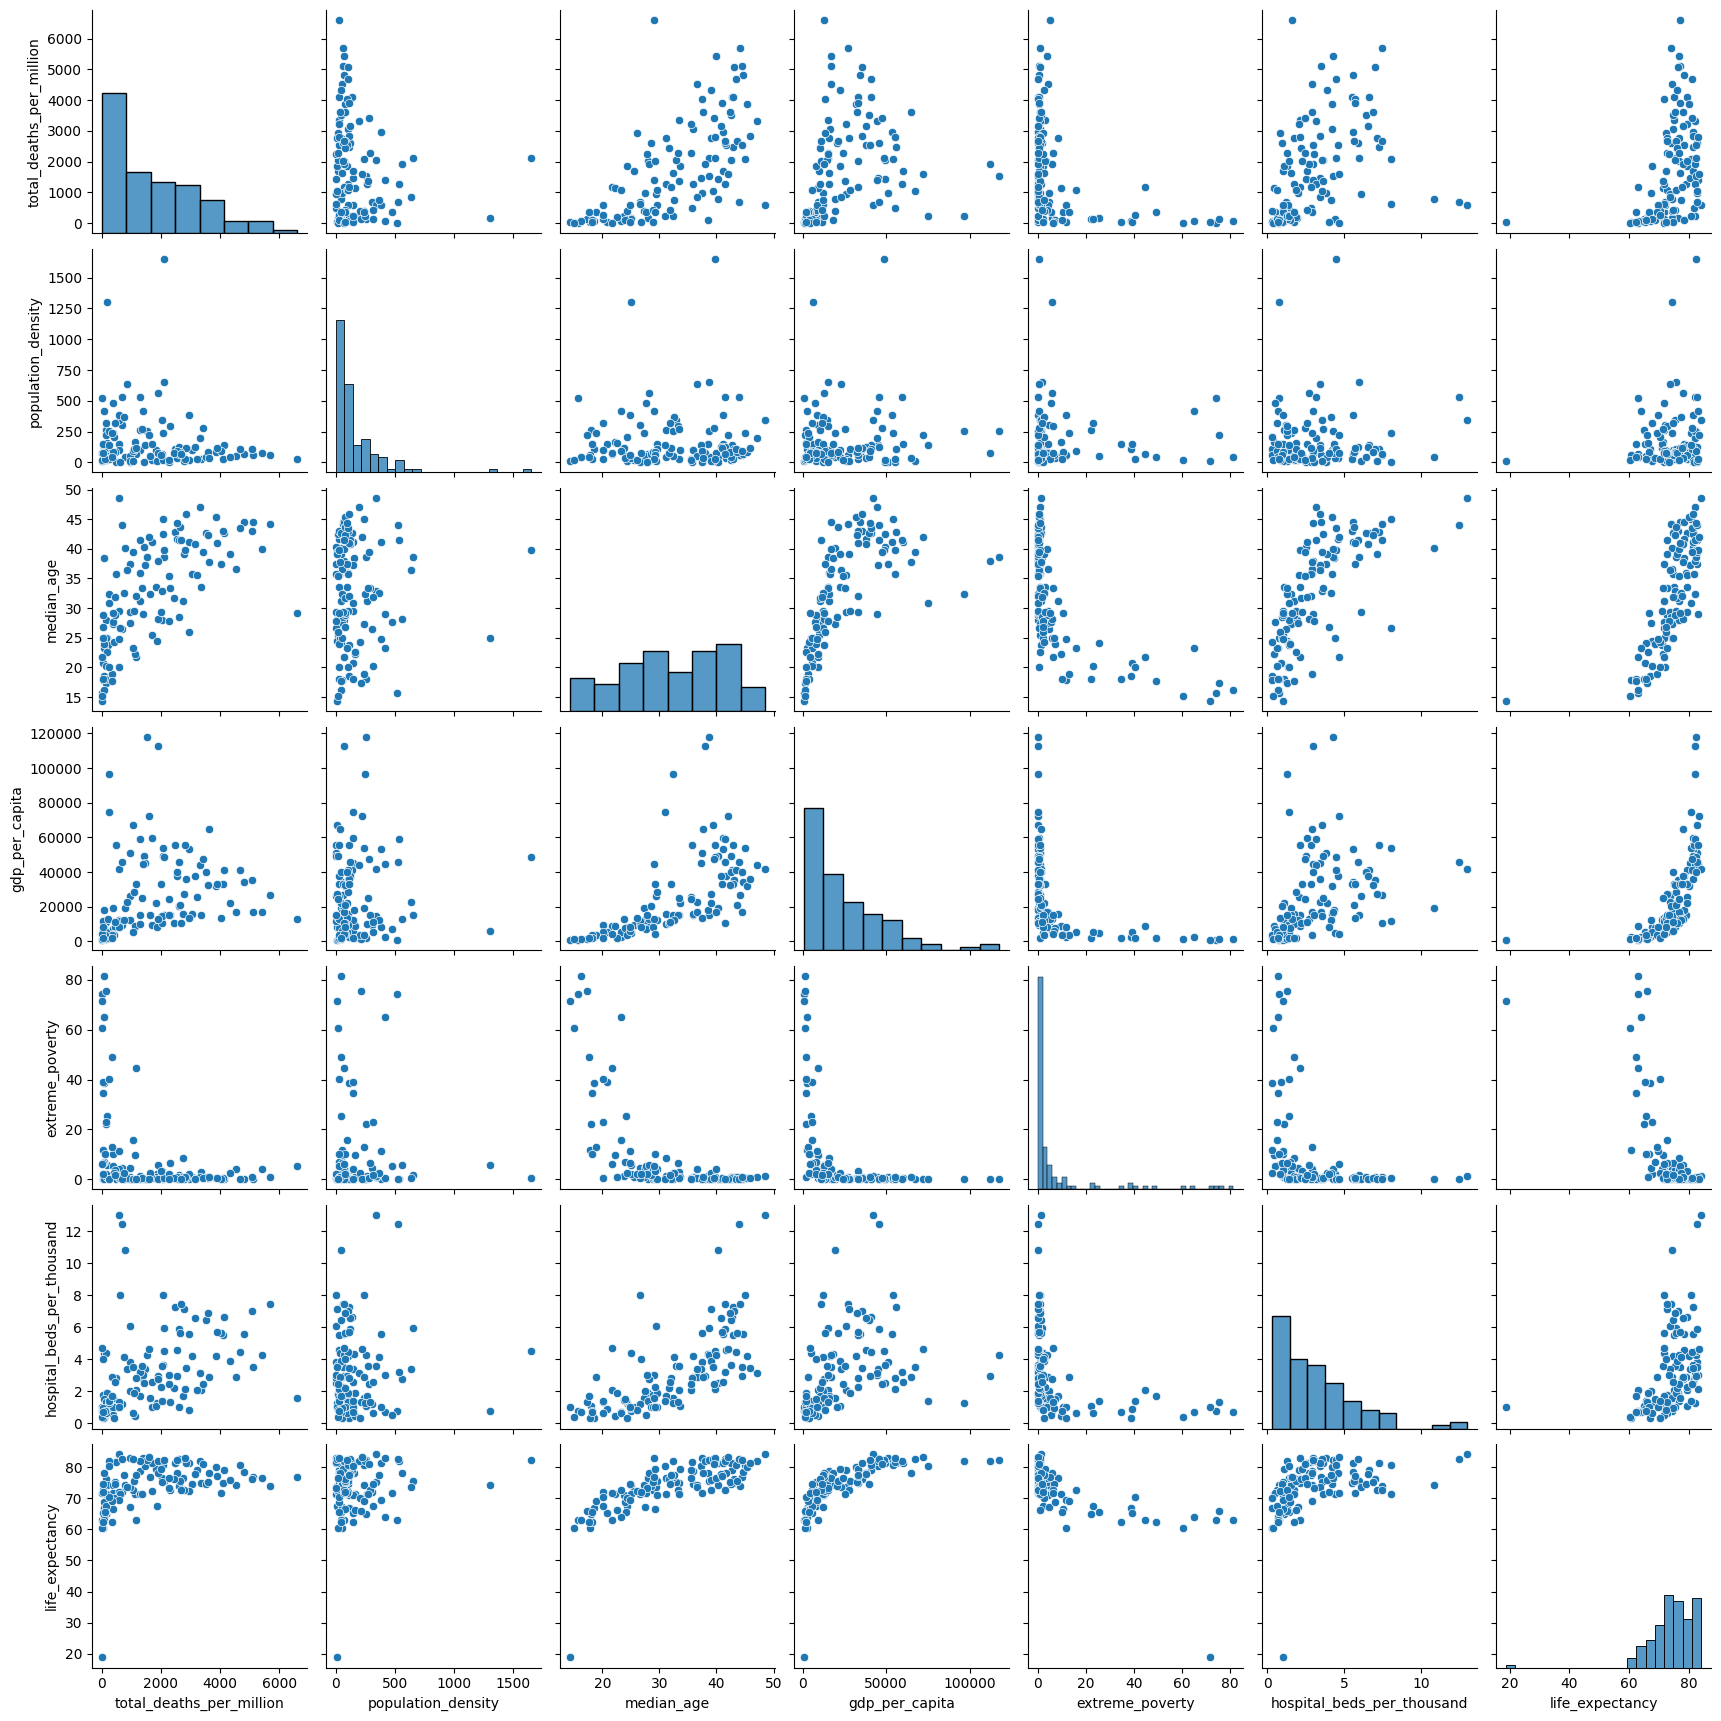

In [17]:
sns.pairplot(df_vars)
pass

We see that total deaths per million surprisingly has positive correlation with variables like life expectancy and hospital beds per thousand. There may be some confounding variables, like more developed countries being able to report deaths more accurately. One correlation that does make sense is that total deaths per million is positively correlated with median age; the elderly are more vulnerable to Covid.

We also see that there are some extreme outliers in variables such as population density and life expectancy. What are the top three and bottom three countries for each variable?

In [18]:
for col in ['total_deaths_per_million'] + newcols:
    print(f'Maximum {col}')
    display(df_vars[df_vars[col].isin(df_vars[col].nlargest(3))])
    print(f'Minimum {col}')
    display(df_vars[df_vars[col].isin(df_vars[col].nsmallest(3))])

Maximum total_deaths_per_million


,country,total_deaths_per_million,population_density,median_age,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy
78547,Bulgaria,5681.0405,62.876400,44.153999,26961.291016,1.011002,7.45,74.034203
371402,North Macedonia,5429.1950,72.967331,39.910000,17128.759766,3.940351,4.28,76.645500
397473,Peru,6603.8574,26.152685,29.096001,12743.942383,5.140564,1.59,76.834000


Minimum total_deaths_per_million


,country,total_deaths_per_million,population_density,median_age,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy
83037,Burundi,1.126033,518.734497,15.672000,708.178284,74.199173,0.79,62.881901
360189,Niger,12.444701,19.982615,15.102000,1274.641724,60.489868,0.39,60.398102
497207,Tajikistan,12.276292,73.364281,21.742001,4137.277832,6.133541,4.67,71.562401


Maximum population_density


...

,country,total_deaths_per_million,population_density,median_age,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy
159821,Ethiopia,60.406296,111.100014,18.528000,2381.165771,38.636116,0.33,66.897102
211429,Guinea,33.297436,57.199806,17.836000,2699.128906,11.650445,0.30,60.431599
348967,Nepal,404.974730,207.292877,24.356001,4001.699951,2.436315,0.30,70.086899


Maximum life_expectancy


,country,total_deaths_per_million,population_density,median_age,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy
251257,Japan,597.56354,342.928894,48.548000,41837.910156,1.200000,12.98,84.054100
489086,Sweden,2798.70920,25.749470,39.728001,55359.343750,0.837948,2.14,83.045998
491331,Switzerland,1611.65940,222.532578,41.960999,72278.210938,0.208695,4.63,83.200302


Minimum life_expectancy


,country,total_deaths_per_million,population_density,median_age,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy
96504,Central African Republic,22.165390,8.183310,14.298,823.982178,71.617348,1.00,18.817699
211429,Guinea,33.297436,57.199806,17.836,2699.128906,11.650445,0.30,60.431599
360189,Niger,12.444701,19.982615,15.102,1274.641724,60.489868,0.39,60.398102


What are the summary statistics for each variable?

In [19]:
df_vars[['total_deaths_per_million'] + newcols].describe()

,total_deaths_per_million,population_density,median_age,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,1708.536884,166.071553,32.240353,24850.688749,8.186099,3.174958,74.160998
std,1541.077936,227.174653,8.853981,22976.961992,17.548718,2.473999,7.752578
min,1.126033,2.173997,14.298000,708.178284,0.000000,0.300000,18.817699
25%,359.920720,43.264902,24.982500,8413.086426,0.308475,1.300000,71.483952
50%,1370.157600,93.519348,32.341000,15616.751953,1.011002,2.600000,74.871902
75%,2668.540400,220.349503,40.051001,37709.212891,5.196102,4.295000,79.246300
max,6603.857400,1650.606201,48.548000,117746.992188,81.361374,12.980000,84.054100


Many of the marginal distributions are heavily right-tailed. It might make more sense to plot these variables on a logarithmic scale.

In [20]:
for col in ['total_deaths_per_million', 'population_density', 'gdp_per_capita', 'extreme_poverty', 'hospital_beds_per_thousand']:
    df_vars[col] = np.log(df_vars[col])
    #df_vars.rename(columns={col: 'log_' + col})

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


New correlation matrix and pairplot:

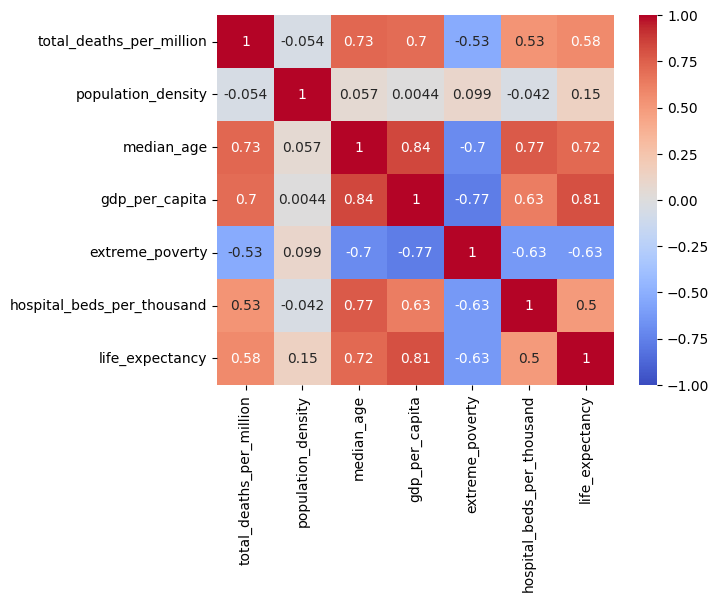

In [21]:
sns.heatmap(df_vars[['total_deaths_per_million'] + newcols].corr(), vmin = -1, vmax = 1, annot = True, cmap = 'coolwarm')
pass

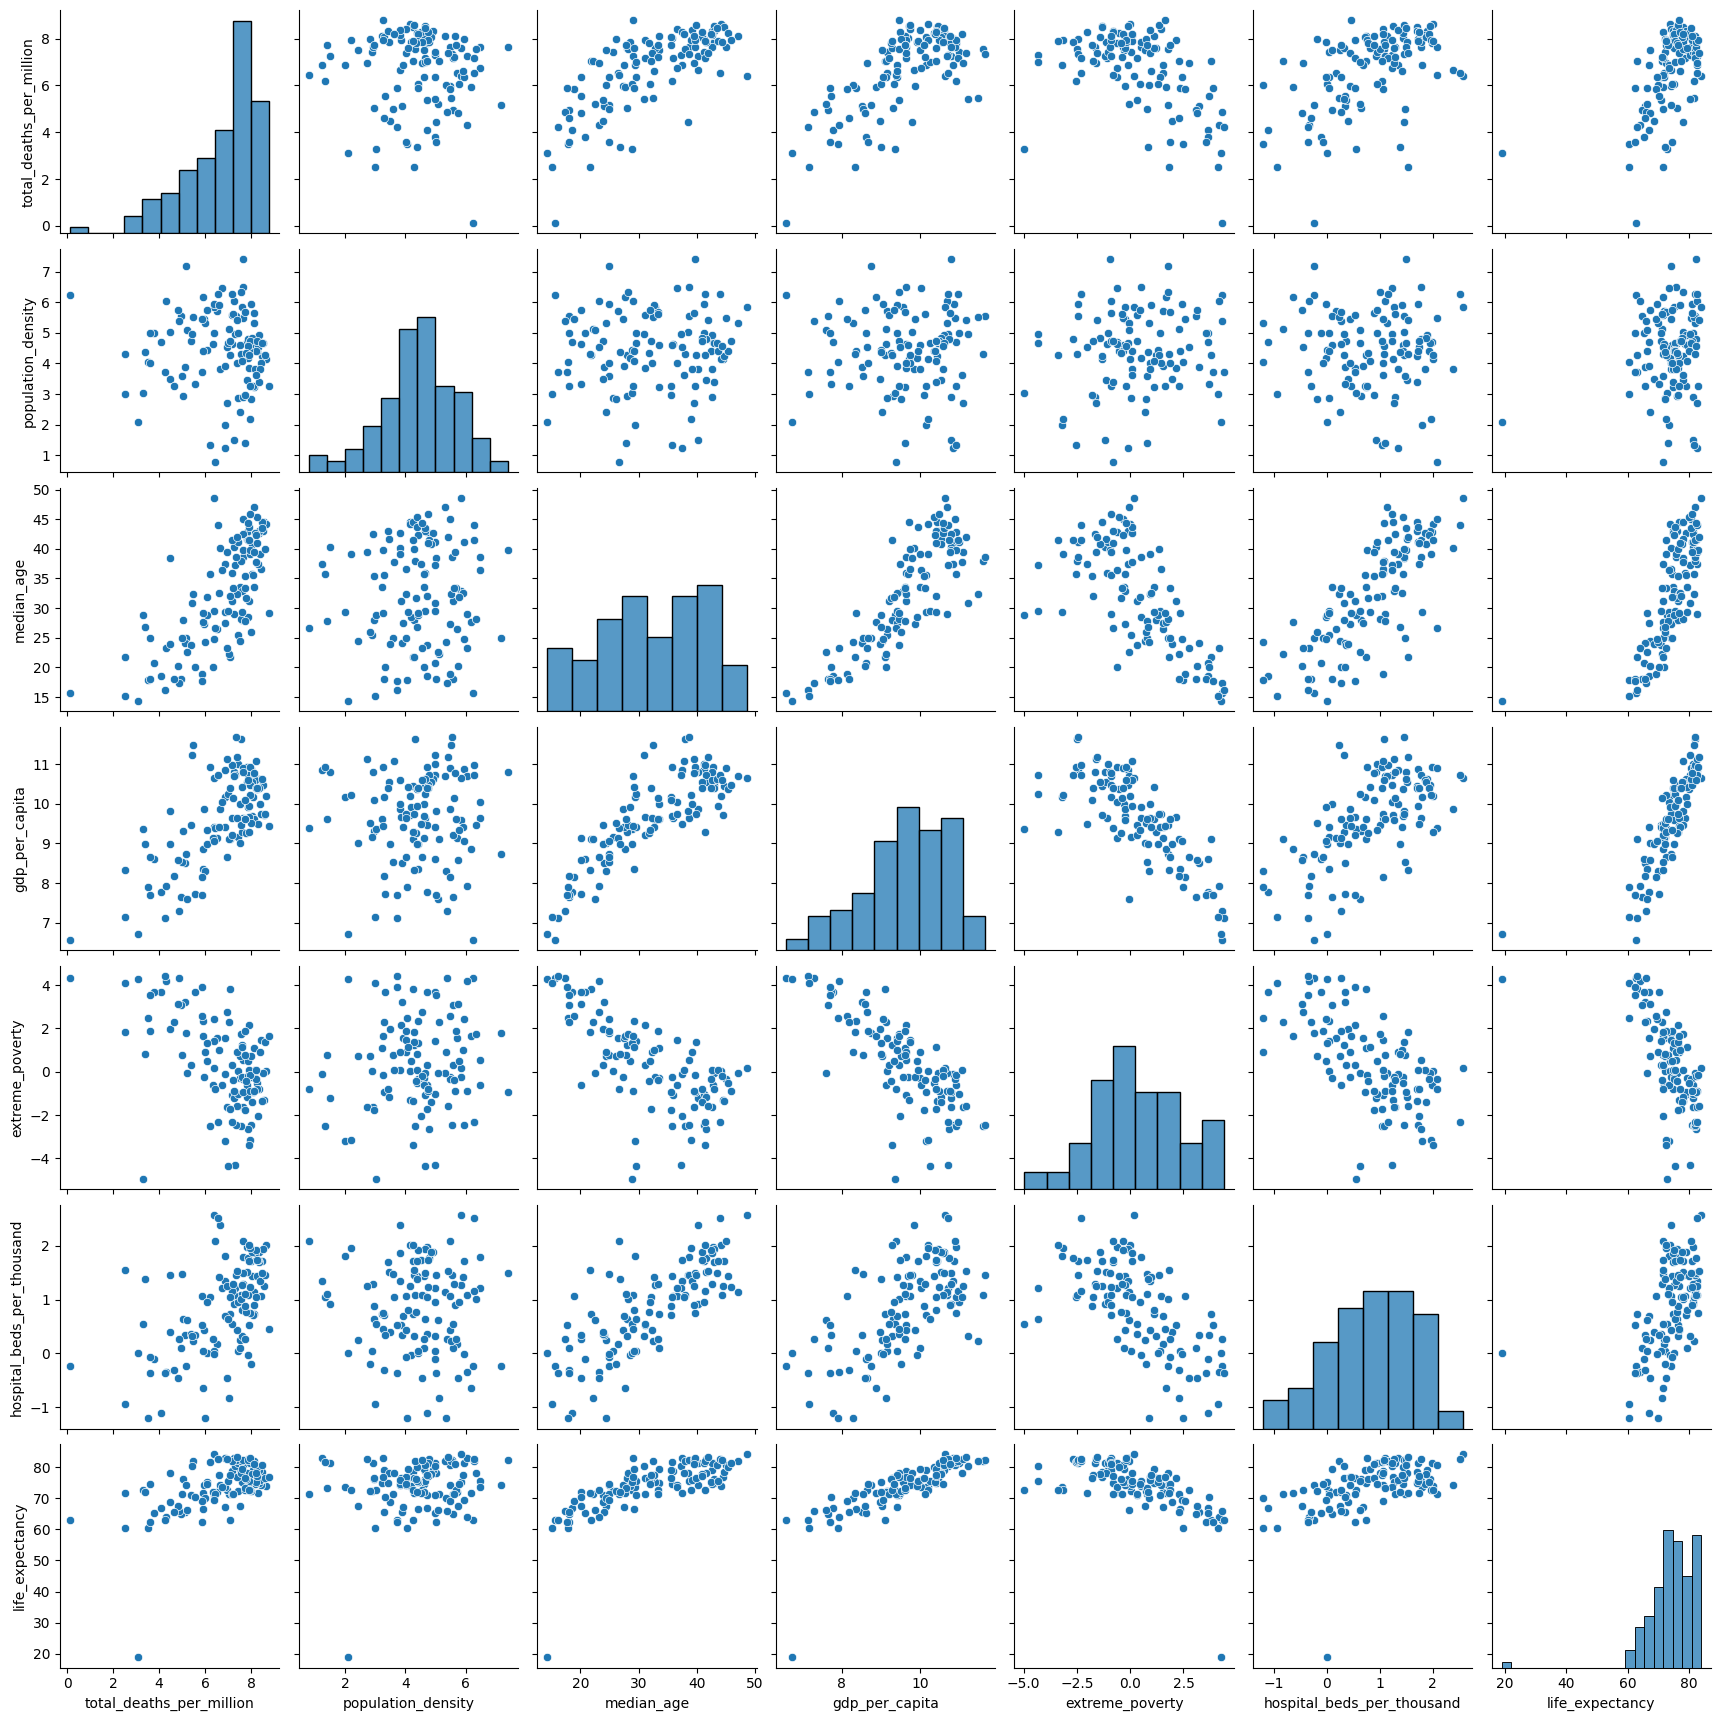

In [22]:
sns.pairplot(df_vars)
pass